# 🔍 Complete Correlation & Feature Engineering Analysis
## CIC-IDS-2018 — Intrusion Detection Dataset

| Section | Description |
|---------|-------------|
| **1** | Setup & Data Loading |
| **2** | Descriptive Statistics & Distributions |
| **3** | Full Correlation Matrix Analysis |
| **4** | Feature–Target Correlation |
| **5** | Multicollinearity Detection (VIF) |
| **6** | Feature Engineering |
| **7** | Engineered Features Validation |
| **8** | Final Feature Selection Summary |

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import warnings
import os
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from scipy import stats
from scipy.stats import pointbiserialr, chi2_contingency
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.preprocessing import PowerTransformer
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier

# ── Style ──────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
OUTPUT_DIR = 'correlation_analysis_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('✅ Libraries loaded')

✅ Libraries loaded


In [2]:
# ── Configuration ──────────────────────────────────────────────────────────
INPUT_FILE   = 'archive/full_df_binary_labels.csv'
TARGET_COL   = 'Label_Binary'
SAMPLE_ROWS  = None   # Use None to load full dataset; set a number for fast exploration
RANDOM_STATE = 42

# Feature groups from the original pipeline
BINARY_FLAGS = ['Protocol', 'RST Flag Cnt', 'PSH Flag Cnt',
                'ACK Flag Cnt', 'URG Flag Cnt', 'ECE Flag Cnt']

NON_NEGATIVE_FEATURES = [
    'Flow Duration', 'Flow IAT Mean', 'Flow IAT Std',
    'Flow IAT Max',  'Flow IAT Min',  'Fwd IAT Tot',
    'Fwd IAT Mean',  'Fwd IAT Std',   'Fwd IAT Max',
    'Fwd IAT Min',   'Bwd IAT Tot',   'Bwd IAT Mean',
    'Bwd IAT Std',   'Bwd IAT Max',   'Bwd IAT Min',
    'Idle Mean',     'Idle Max',      'Idle Min',
    'Tot Fwd Pkts',  'Tot Bwd Pkts',  'TotLen Fwd Pkts',
    'TotLen Bwd Pkts', 'Flow Byts/s', 'Flow Pkts/s'
]

# ── Load ───────────────────────────────────────────────────────────────────
print(f'📂 Loading data from: {INPUT_FILE}')
if SAMPLE_ROWS:
    df = pd.read_csv(INPUT_FILE, nrows=SAMPLE_ROWS)
    print(f'   (Sampled {SAMPLE_ROWS:,} rows for speed)')
else:
    df = pd.read_csv(INPUT_FILE)

df = df.drop(columns=['Label'], errors='ignore')

# Remove corrupt rows (impossible negatives)
cols_to_check = [c for c in NON_NEGATIVE_FEATURES if c in df.columns]
mask = (df[cols_to_check] < 0).any(axis=1)
df   = df[~mask].reset_index(drop=True)

# Inf → NaN → drop
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

print(f'\n✅ Clean dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'\nClass distribution:')
print(df[TARGET_COL].value_counts())

FEATURE_COLS = [c for c in df.columns if c != TARGET_COL]
X = df[FEATURE_COLS]
y = df[TARGET_COL]

📂 Loading data from: archive/full_df_binary_labels.csv

✅ Clean dataset: 16,232,928 rows × 58 columns

Class distribution:
Label_Binary
0    13484693
1     2748235
Name: count, dtype: int64


## 2. Descriptive Statistics & Distributions

In [3]:
print('=' * 70)
print('📊 DESCRIPTIVE STATISTICS')
print('=' * 70)
desc = X.describe().T
desc['skewness'] = X.skew()
desc['kurtosis'] = X.kurtosis()
desc['cv']       = desc['std'] / (desc['mean'].abs() + 1e-9)  # coefficient of variation
desc.sort_values('skewness', ascending=False, inplace=True)
display(desc.style.background_gradient(cmap='RdYlGn_r', subset=['skewness', 'kurtosis']))

📊 DESCRIPTIVE STATISTICS


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis,cv
Pkt Len Var,16232928.000000,41170.573450,212977.391589,0.000000,0.000000,1045.333333,82647.349673,519000000.000000,1863.598432,4295780.520284,5.173049
Subflow Fwd Byts,16232928.000000,973.038120,62169.087302,0.000000,0.000000,43.000000,456.000000,144391846.000000,836.684803,1808721.537133,63.891728
TotLen Fwd Pkts,16232928.000000,973.038120,62169.087302,0.000000,0.000000,43.000000,456.000000,144391846.000000,836.684803,1808721.537133,63.891728
Tot Bwd Pkts,16232928.000000,6.312711,164.025714,0.000000,0.000000,1.000000,4.000000,123118.000000,170.803847,61867.768945,25.983402
Subflow Bwd Pkts,16232928.000000,6.312711,164.025714,0.000000,0.000000,1.000000,4.000000,123118.000000,170.803847,61867.768945,25.983402
Bwd Header Len,16232928.000000,133.093599,3265.497986,0.000000,0.000000,16.000000,104.000000,2462372.000000,170.409358,62185.382182,24.535350
TotLen Bwd Pkts,16232928.000000,4730.935707,234465.964526,0.000000,0.000000,101.000000,582.000000,156360426.000000,160.056647,49375.749438,49.560167
Subflow Bwd Byts,16232928.000000,4730.913231,234455.674803,0.000000,0.000000,101.000000,582.000000,156360426.000000,160.017857,49348.969871,49.558228
Down/Up Ratio,16232928.000000,0.496437,0.996728,0.000000,0.000000,0.000000,1.000000,311.000000,128.479353,27452.353839,2.007764
Fwd Act Data Pkts,16232928.000000,19.895296,1519.917315,0.000000,0.000000,0.000000,1.000000,309628.000000,88.757932,8298.144528,76.395812


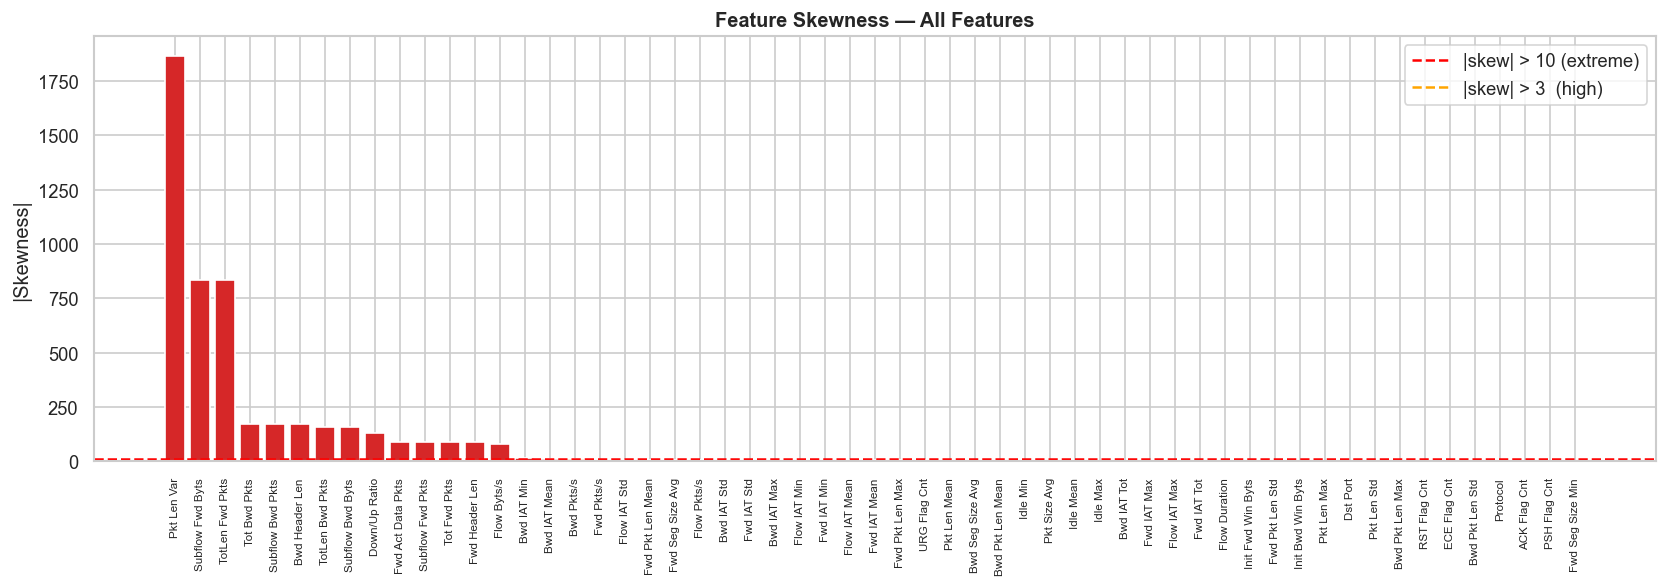

Extreme skew (>10): 16 features — need PowerTransform or log1p
High skew   (3-10): 25  features — consider PowerTransform
Low skew    (<3)  : 16  features — StandardScaler sufficient


In [4]:
# ── Skewness bar chart ─────────────────────────────────────────────────────
skew_vals = X.skew().abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
colors  = ['#d62728' if v > 10 else '#ff7f0e' if v > 3 else '#2ca02c' for v in skew_vals]
ax.bar(skew_vals.index, skew_vals.values, color=colors)
ax.axhline(10, color='red',    linestyle='--', label='|skew| > 10 (extreme)')
ax.axhline(3,  color='orange', linestyle='--', label='|skew| > 3  (high)')
ax.set_xticklabels(skew_vals.index, rotation=90, fontsize=7)
ax.set_ylabel('|Skewness|')
ax.set_title('Feature Skewness — All Features', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/01_feature_skewness.png', bbox_inches='tight')
plt.show()

# Summary
extreme = (skew_vals > 10).sum()
high    = ((skew_vals > 3) & (skew_vals <= 10)).sum()
low     = (skew_vals <= 3).sum()
print(f'Extreme skew (>10): {extreme} features — need PowerTransform or log1p')
print(f'High skew   (3-10): {high}  features — consider PowerTransform')
print(f'Low skew    (<3)  : {low}  features — StandardScaler sufficient')

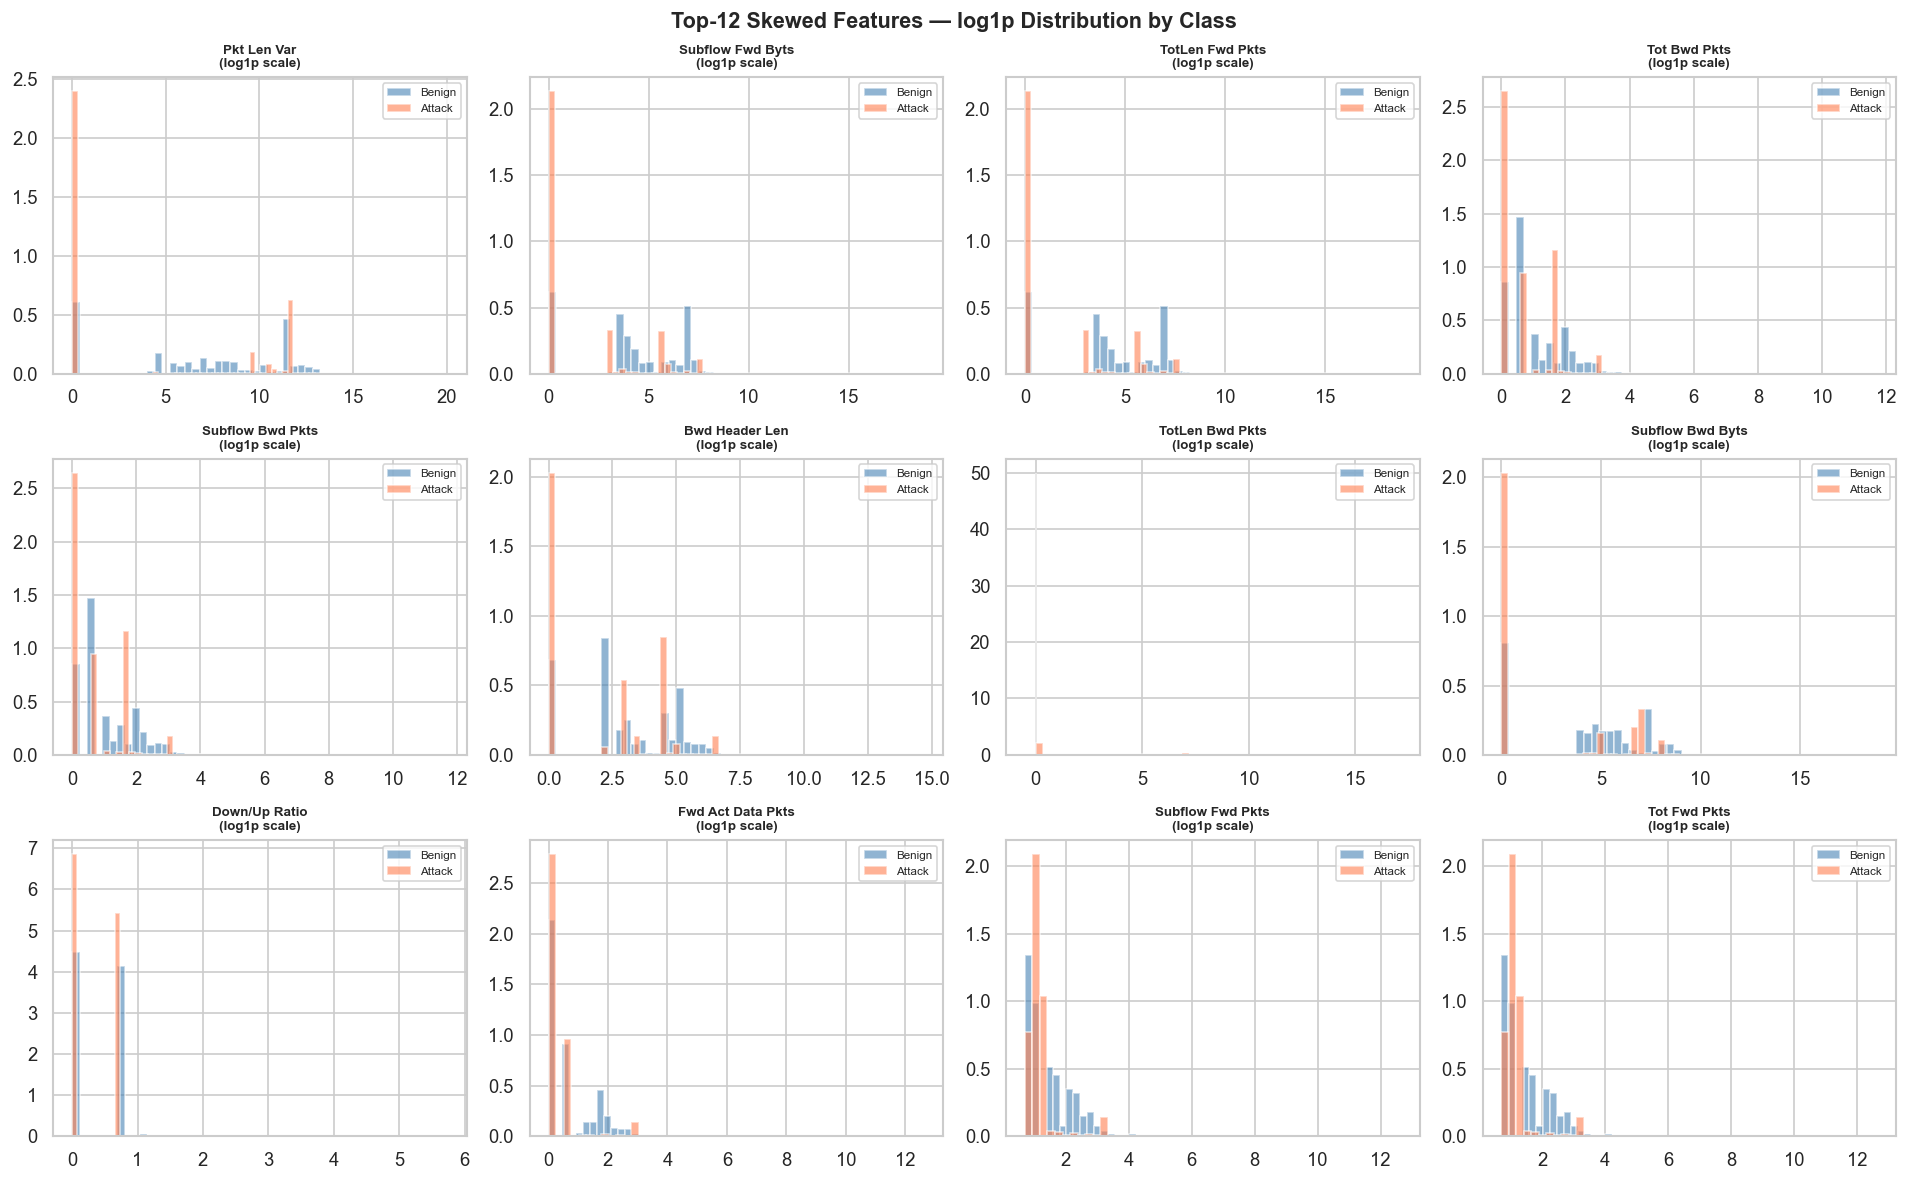

In [5]:
# ── Distribution grid: top-12 most-skewed features ────────────────────────
top12 = skew_vals.head(12).index.tolist()
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(top12):
    benign = df[col][df[TARGET_COL] == 0]
    attack = df[col][df[TARGET_COL] == 1]
    axes[i].hist(np.log1p(benign.clip(lower=0)), bins=50, alpha=0.6, label='Benign', color='steelblue', density=True)
    axes[i].hist(np.log1p(attack.clip(lower=0)), bins=50, alpha=0.6, label='Attack', color='coral',     density=True)
    axes[i].set_title(f'{col}\n(log1p scale)', fontsize=8, fontweight='bold')
    axes[i].legend(fontsize=7)

plt.suptitle('Top-12 Skewed Features — log1p Distribution by Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/02_top12_distributions.png', bbox_inches='tight')
plt.show()

## 3. Full Correlation Matrix Analysis

Computing Pearson correlation matrix...


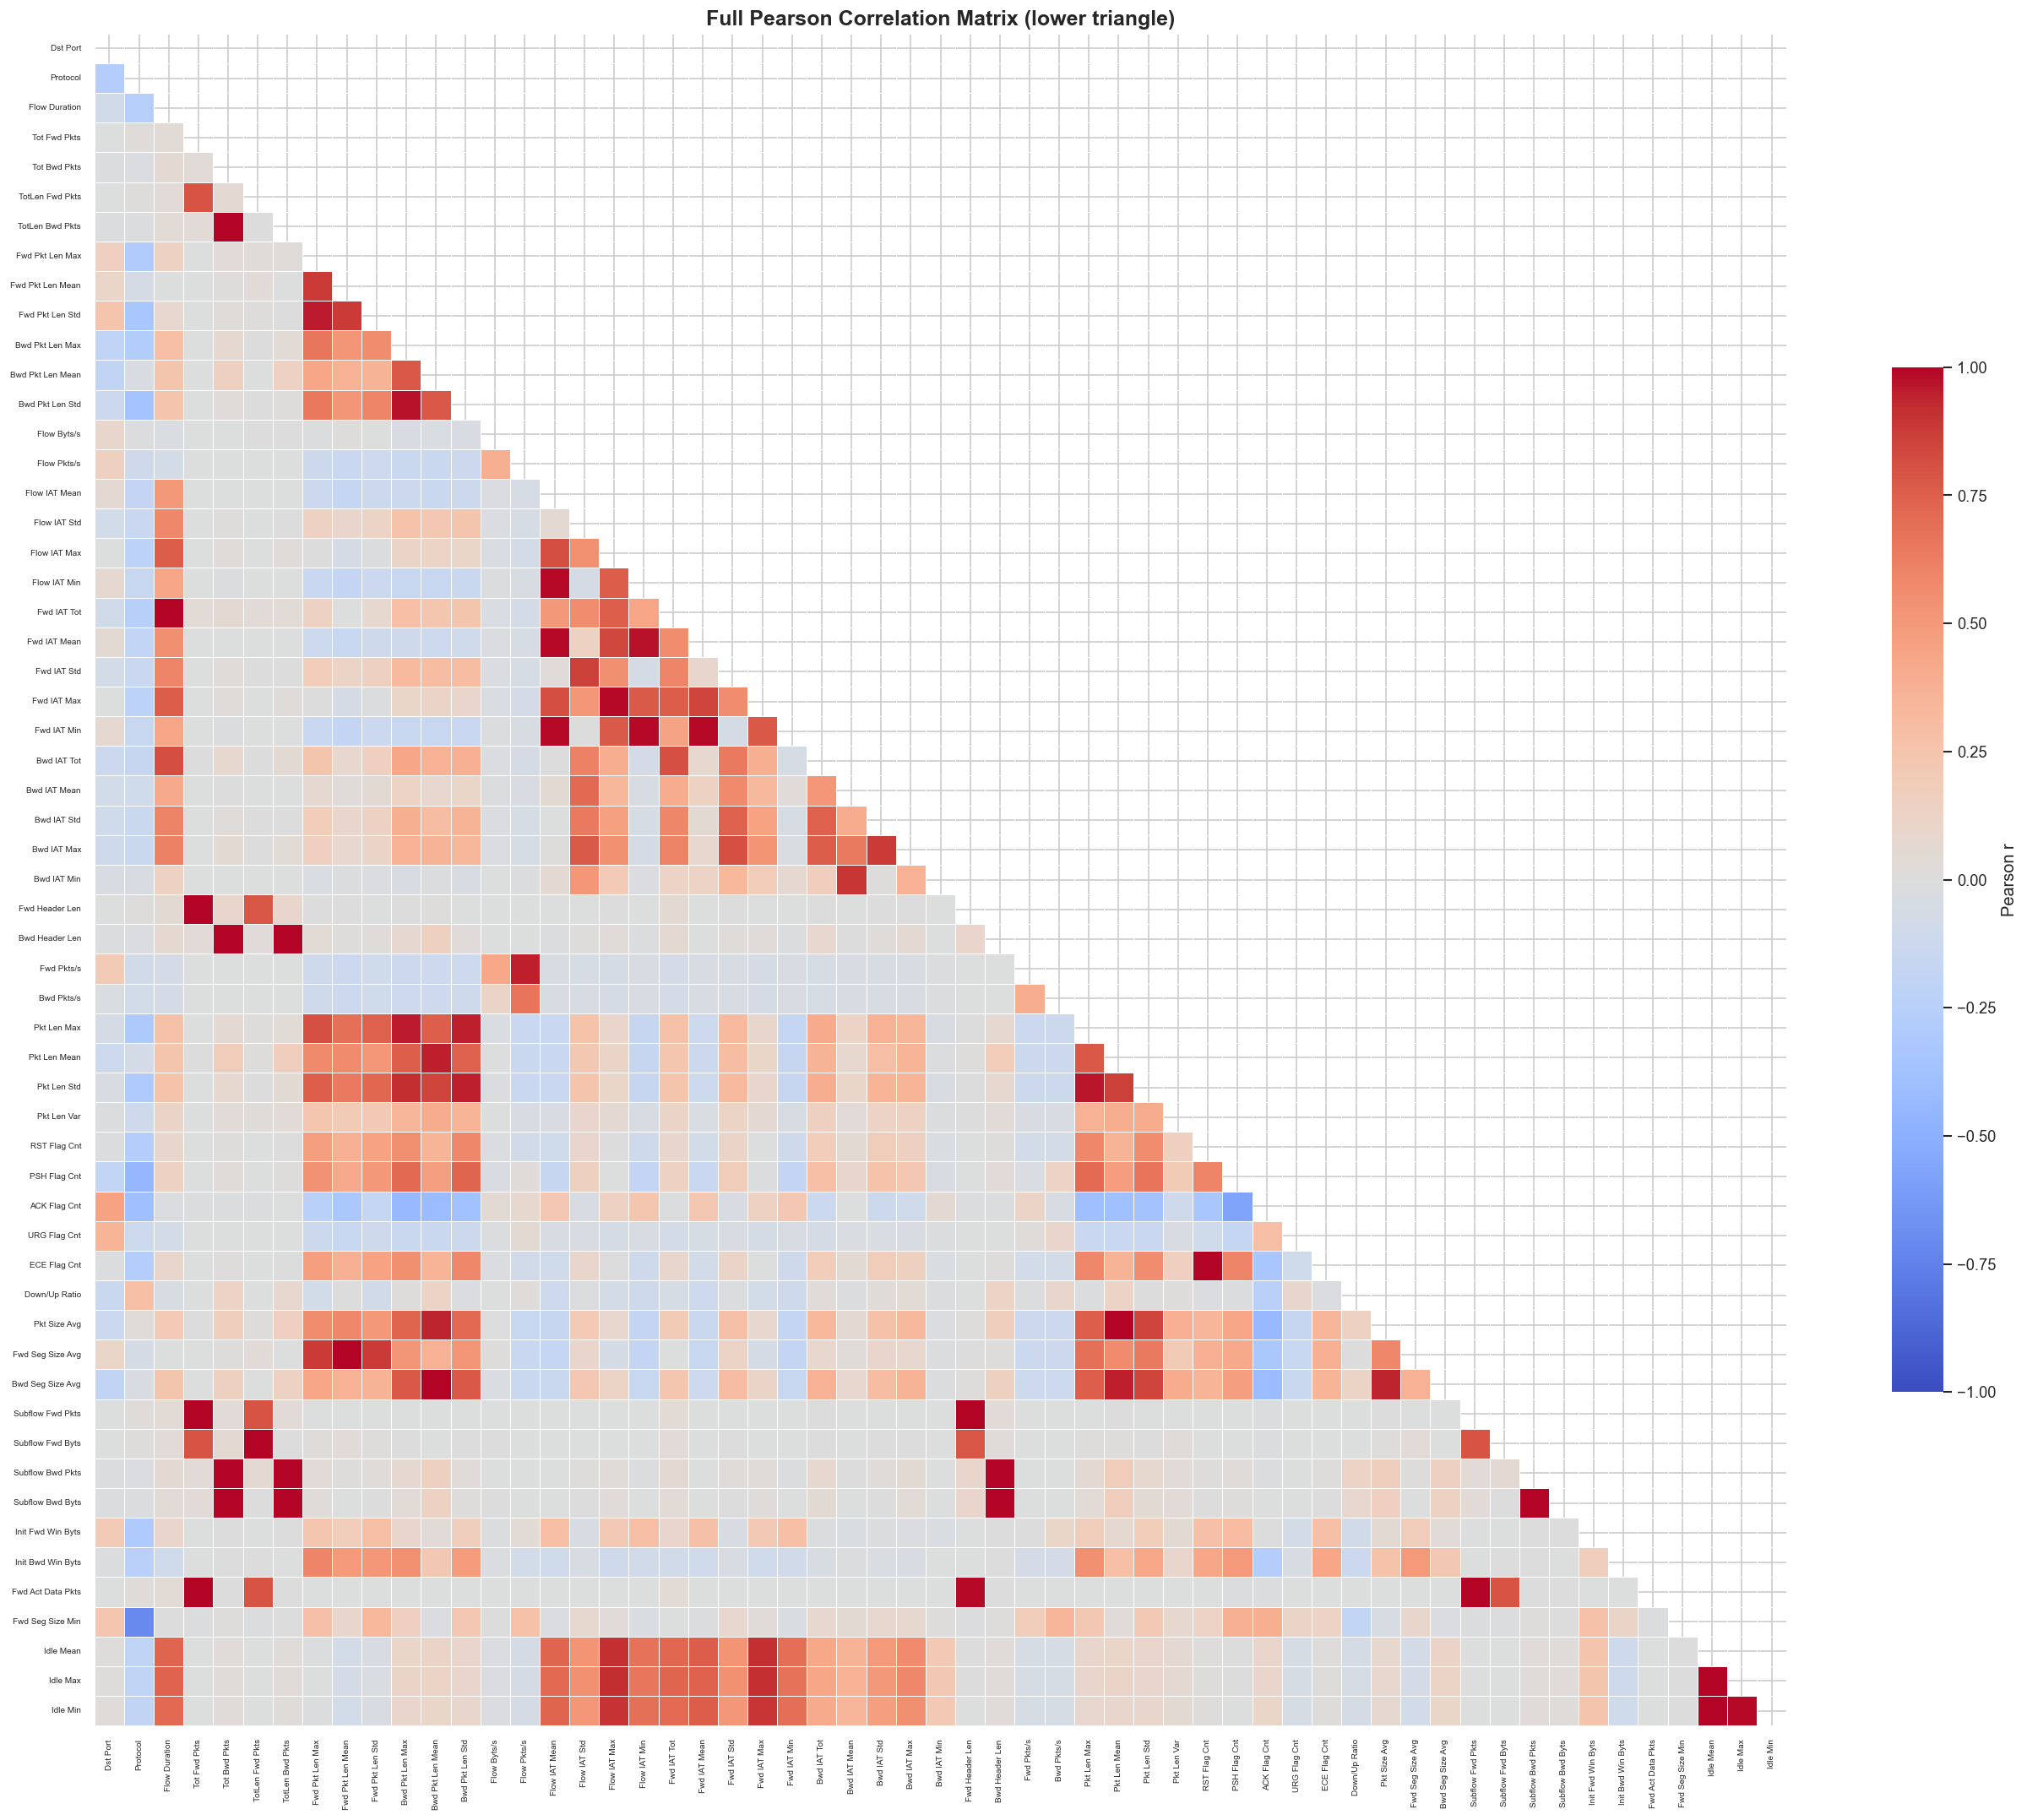

✅ Full correlation matrix saved


In [6]:
print('Computing Pearson correlation matrix...')
corr_matrix = X.corr(method='pearson')

# ── Full heatmap ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(22, 18))
mask    = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    annot=False,
    square=True,
    linewidths=0.3,
    cbar_kws={'shrink': 0.6, 'label': 'Pearson r'},
    ax=ax
)
ax.set_title('Full Pearson Correlation Matrix (lower triangle)', fontsize=15, fontweight='bold')
ax.tick_params(axis='x', labelsize=6, rotation=90)
ax.tick_params(axis='y', labelsize=6)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03_full_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Full correlation matrix saved')

In [7]:
# ── Highly correlated pairs (|r| > threshold) ─────────────────────────────
CORR_THRESHOLD = 0.90

upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = (
    upper_tri.stack()
    .reset_index()
    .rename(columns={'level_0': 'Feature_A', 'level_1': 'Feature_B', 0: 'r'})
)
high_corr_pairs['|r|'] = high_corr_pairs['r'].abs()
high_corr_pairs = high_corr_pairs[high_corr_pairs['|r|'] >= CORR_THRESHOLD].sort_values('|r|', ascending=False)

print(f'\n🔴 Highly correlated pairs (|r| ≥ {CORR_THRESHOLD}): {len(high_corr_pairs)} pairs')
print(f'   → These are candidates for REMOVAL (multicollinearity risk)\n')
display(high_corr_pairs.reset_index(drop=True))


🔴 Highly correlated pairs (|r| ≥ 0.9): 49 pairs
   → These are candidates for REMOVAL (multicollinearity risk)



,Feature_A,Feature_B,r,|r|
0,Tot Fwd Pkts,Subflow Fwd Pkts,1.000000,1.000000
1,TotLen Fwd Pkts,Subflow Fwd Byts,1.000000,1.000000
2,Tot Bwd Pkts,Subflow Bwd Pkts,1.000000,1.000000
3,Fwd Pkt Len Mean,Fwd Seg Size Avg,1.000000,1.000000
4,Bwd Pkt Len Mean,Bwd Seg Size Avg,1.000000,1.000000
5,TotLen Bwd Pkts,Subflow Bwd Byts,1.000000,1.000000
6,RST Flag Cnt,ECE Flag Cnt,0.999987,0.999987
7,Tot Fwd Pkts,Fwd Act Data Pkts,0.999189,0.999189
8,Subflow Fwd Pkts,Fwd Act Data Pkts,0.999189,0.999189
9,Tot Bwd Pkts,Bwd Header Len,0.997798,0.997798


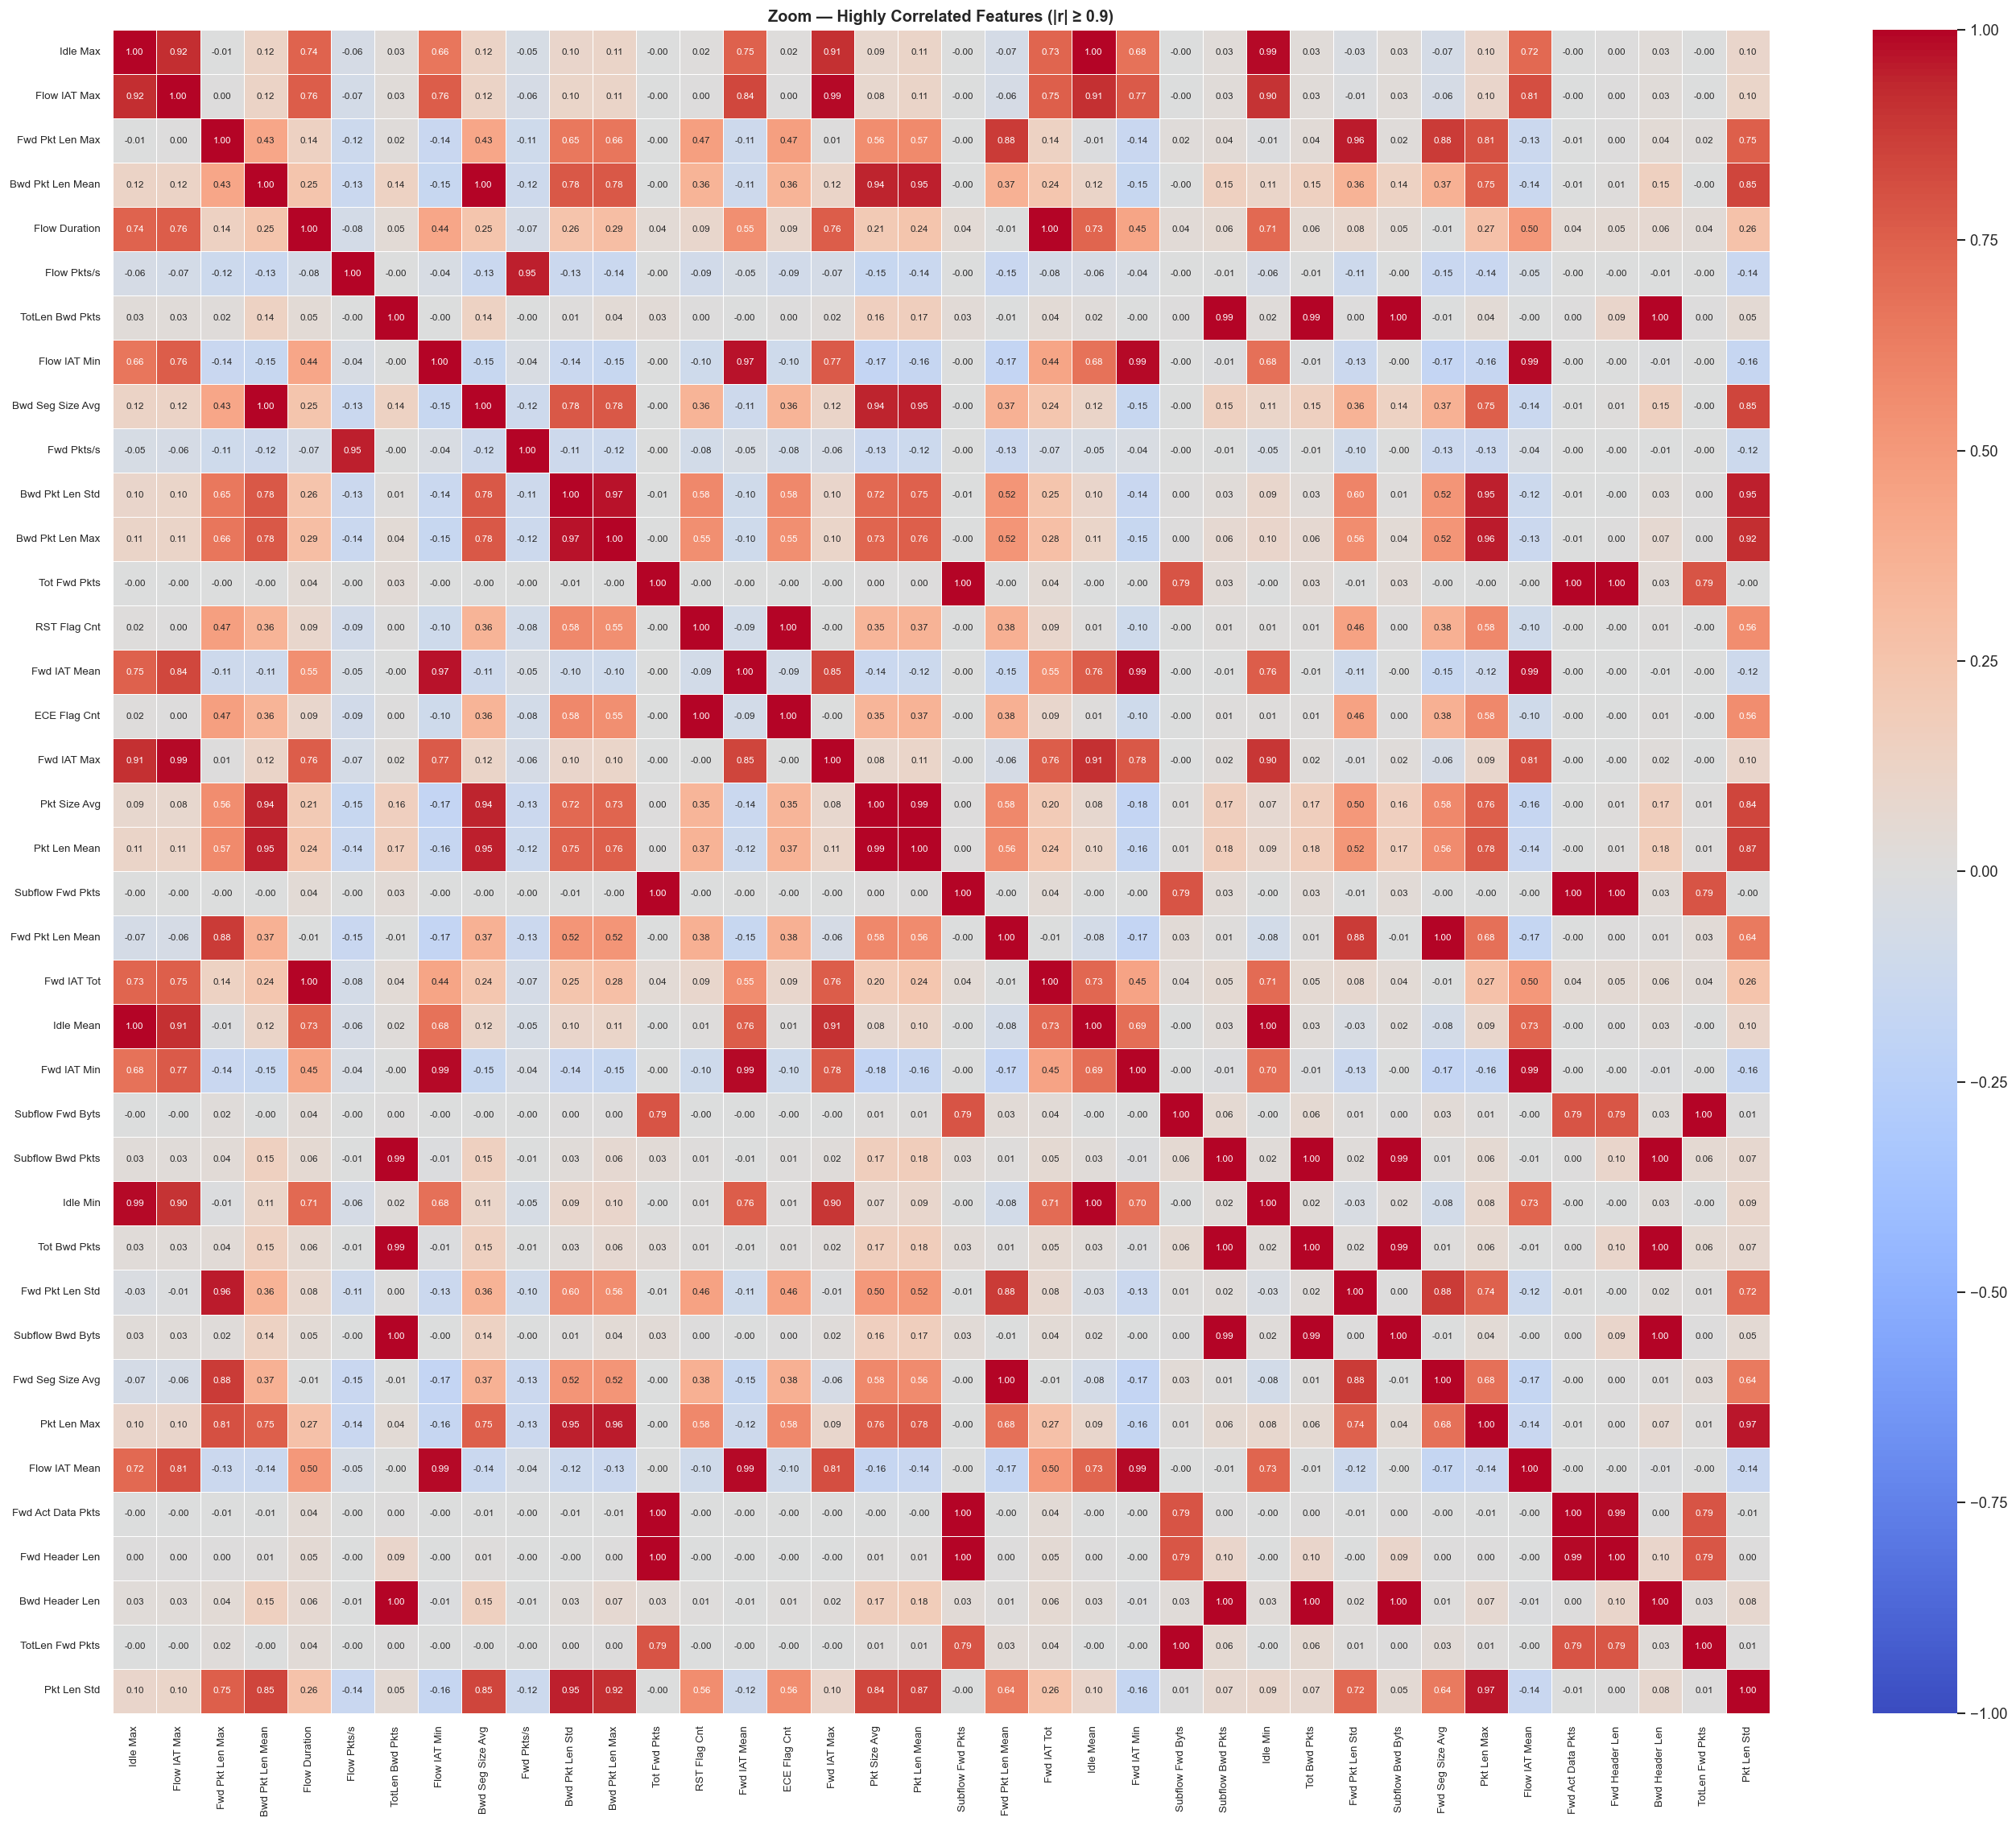

In [8]:
# ── Zoom-in heatmap for highly correlated features ─────────────────────────
redundant_features = list(set(
    high_corr_pairs['Feature_A'].tolist() + high_corr_pairs['Feature_B'].tolist()
))

if len(redundant_features) > 1:
    sub_corr = corr_matrix.loc[redundant_features, redundant_features]
    fig, ax  = plt.subplots(figsize=(max(10, len(redundant_features)*0.6),
                                     max(8,  len(redundant_features)*0.5)))
    sns.heatmap(
        sub_corr, annot=True, fmt='.2f', cmap='coolwarm',
        center=0, vmin=-1, vmax=1, linewidths=0.5,
        annot_kws={'size': 7}, ax=ax
    )
    ax.set_title(f'Zoom — Highly Correlated Features (|r| ≥ {CORR_THRESHOLD})',
                 fontweight='bold')
    ax.tick_params(axis='x', rotation=90, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/04_high_corr_zoom.png', bbox_inches='tight')
    plt.show()
else:
    print('No highly correlated features found at this threshold.')

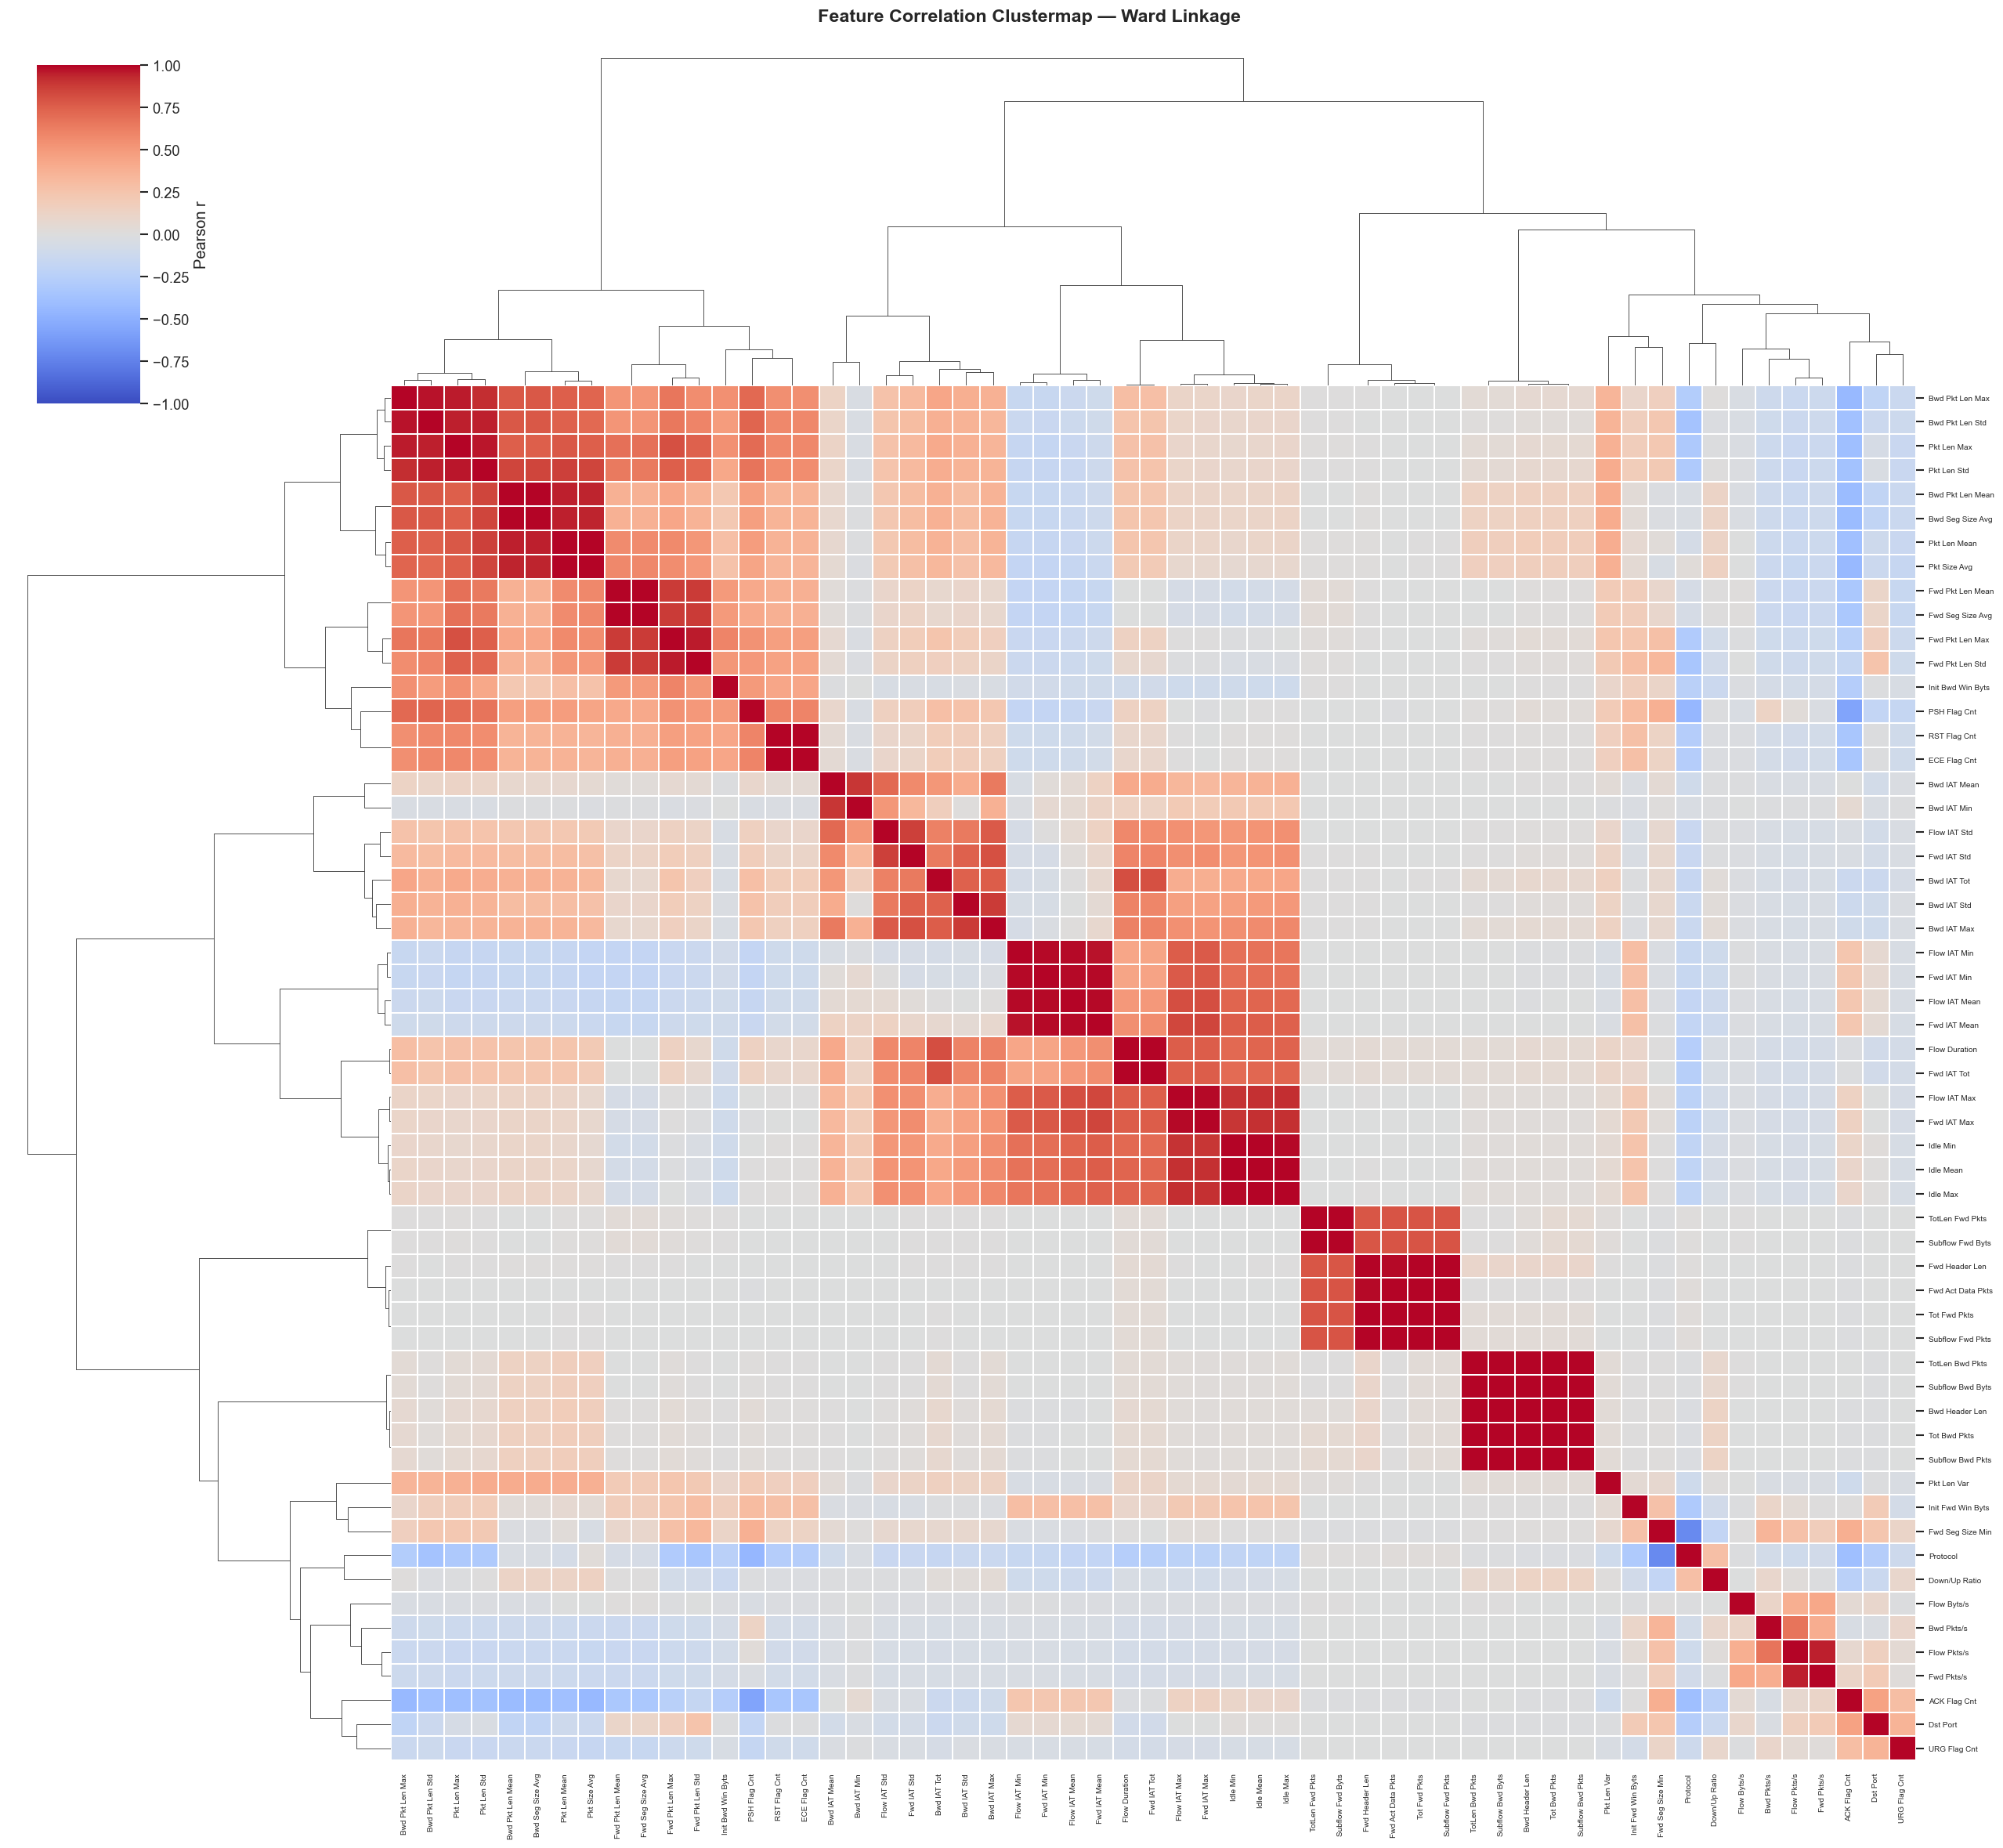

✅ Clustermap saved — look for dark-red blocks indicating feature groups


In [9]:
# ── Clustermap — finds natural groups of correlated features ───────────────
fig = sns.clustermap(
    corr_matrix,
    method='ward',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    figsize=(22, 20),
    xticklabels=True,
    yticklabels=True,
    linewidths=0.2,
    cbar_kws={'label': 'Pearson r'}
)
fig.ax_heatmap.tick_params(axis='x', labelsize=6, rotation=90)
fig.ax_heatmap.tick_params(axis='y', labelsize=6)
fig.fig.suptitle('Feature Correlation Clustermap — Ward Linkage',
                 fontsize=14, fontweight='bold', y=1.01)
fig.savefig(f'{OUTPUT_DIR}/05_clustermap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Clustermap saved — look for dark-red blocks indicating feature groups')

## 4. Feature–Target Correlation

In [10]:
print('Computing feature–target correlations...')

# Point-biserial correlation (binary target)
pb_results = {}
for col in FEATURE_COLS:
    r, p = pointbiserialr(y, X[col])
    pb_results[col] = {'r': r, 'p_value': p, '|r|': abs(r)}

pb_df = pd.DataFrame(pb_results).T.sort_values('|r|', ascending=False)
pb_df['significance'] = pb_df['p_value'].apply(
    lambda p: '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
)
print('\nTop-20 features most correlated with the target:')
display(pb_df.head(20))

Computing feature–target correlations...

Top-20 features most correlated with the target:


,r,p_value,|r|,significance
Fwd Seg Size Min,0.429296,0.0,0.429296,***
Bwd Pkts/s,0.260203,0.0,0.260203,***
Protocol,-0.233374,0.0,0.233374,***
Fwd Pkt Len Mean,-0.227323,0.0,0.227323,***
Fwd Seg Size Avg,-0.227323,0.0,0.227323,***
ACK Flag Cnt,0.220465,0.0,0.220465,***
Init Fwd Win Byts,0.218390,0.0,0.218390,***
Pkt Size Avg,-0.204211,0.0,0.204211,***
Fwd Pkt Len Max,-0.187779,0.0,0.187779,***
Dst Port,-0.183407,0.0,0.183407,***


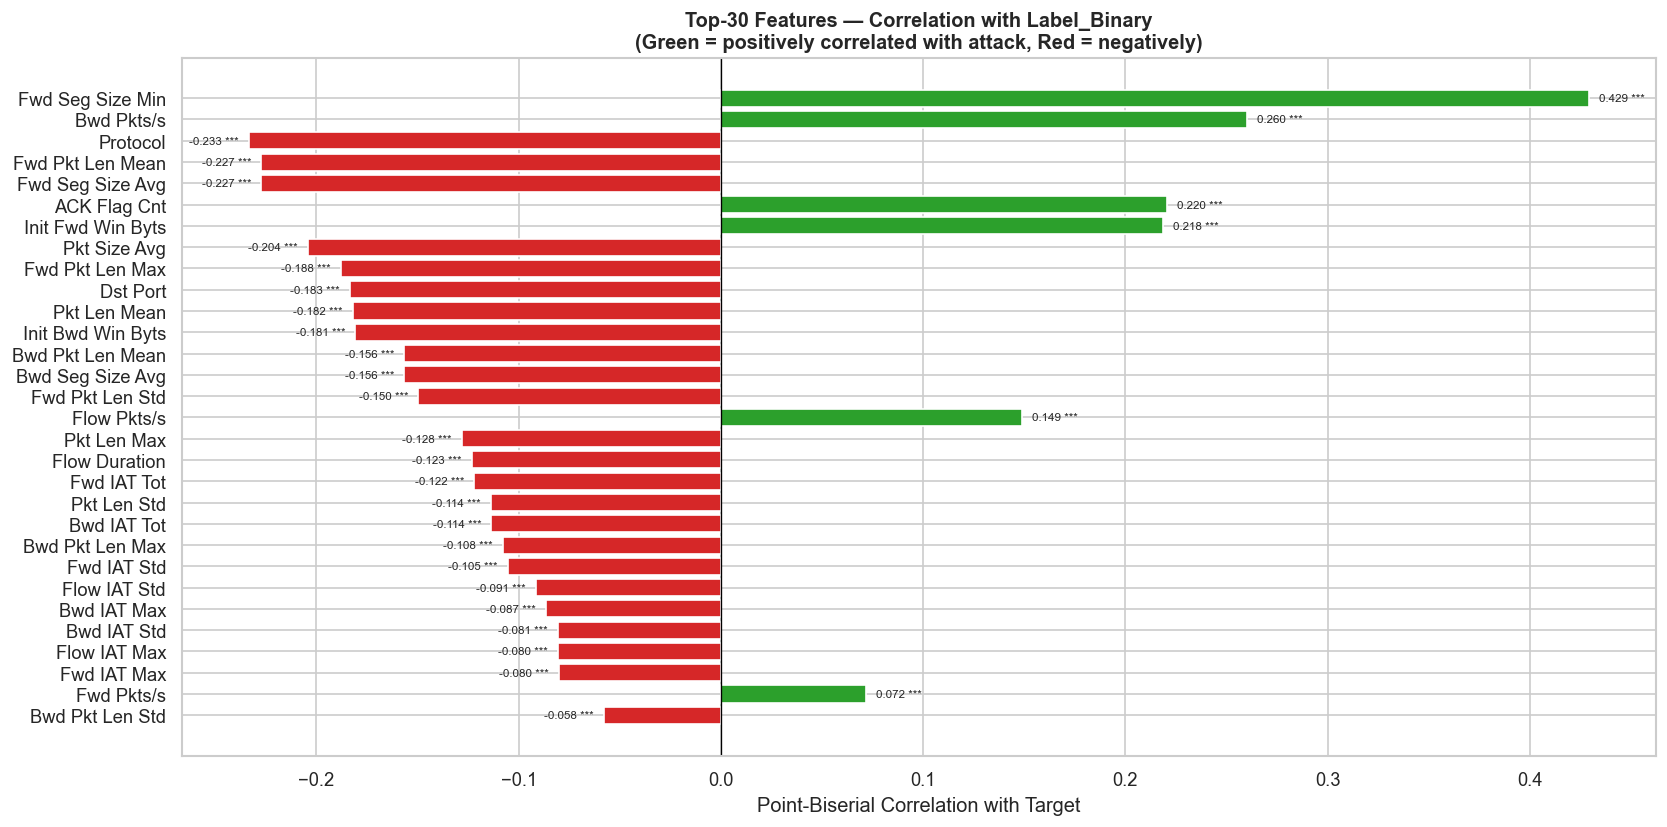

In [11]:
# ── Point-Biserial chart ───────────────────────────────────────────────────
top_n = 30
plot_df = pb_df.head(top_n).copy()

fig, ax = plt.subplots(figsize=(14, 7))
colors  = ['#d62728' if r < 0 else '#2ca02c' for r in plot_df['r']]
bars    = ax.barh(plot_df.index[::-1], plot_df['r'][::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Point-Biserial Correlation with Target')
ax.set_title(f'Top-{top_n} Features — Correlation with Label_Binary\n'
             '(Green = positively correlated with attack, Red = negatively)',
             fontweight='bold')
for bar, (idx, row) in zip(bars[::-1], plot_df.iterrows()):
    ax.text(bar.get_width() + 0.005 * np.sign(bar.get_width()),
            bar.get_y() + bar.get_height()/2,
            f"{row['r']:.3f} {row['significance']}",
            va='center', ha='left' if bar.get_width() >= 0 else 'right', fontsize=7)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/06_feature_target_correlation.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── Mutual Information (captures non-linear relationships) ─────────────────
print('Computing Mutual Information (non-linear)... (this may take ~1 min)')
mi_scores = mutual_info_classif(X, y, random_state=RANDOM_STATE)
mi_df     = pd.Series(mi_scores, index=FEATURE_COLS).sort_values(ascending=False)
mi_df     = mi_df.reset_index()
mi_df.columns = ['Feature', 'MI_Score']

fig, ax = plt.subplots(figsize=(14, 6))
ax.barh(mi_df['Feature'][:30][::-1], mi_df['MI_Score'][:30][::-1], color='steelblue')
ax.set_xlabel('Mutual Information Score')
ax.set_title('Top-30 Features — Mutual Information with Target\n'
             '(captures non-linear relationships)', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/07_mutual_information.png', bbox_inches='tight')
plt.show()

print('\nTop-20 by Mutual Information:')
display(mi_df.head(20))

Computing Mutual Information (non-linear)... (this may take ~1 min)


In [ ]:
# ── Random Forest Feature Importance ──────────────────────────────────────
print('Training quick Random Forest for feature importances...')
rf_quick = RandomForestClassifier(n_estimators=100, max_depth=8,
                                   n_jobs=-1, random_state=RANDOM_STATE)
rf_quick.fit(X, y)
rf_imp = pd.Series(rf_quick.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
ax.barh(rf_imp.index[:30][::-1], rf_imp.values[:30][::-1], color='coral')
ax.set_xlabel('Gini Importance')
ax.set_title('Top-30 Features — Random Forest Importance', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/08_rf_importance.png', bbox_inches='tight')
plt.show()

# Combined ranking table
rank_df = pd.DataFrame({
    'PB_corr_rank': pb_df['|r|'].rank(ascending=False).astype(int),
    'MI_rank':      mi_df.set_index('Feature')['MI_Score'].rank(ascending=False).astype(int),
    'RF_rank':      rf_imp.rank(ascending=False).astype(int)
})
rank_df['mean_rank'] = rank_df.mean(axis=1)
rank_df = rank_df.sort_values('mean_rank')
print('\n📋 Combined Feature Ranking (lower mean_rank = more important):')
display(rank_df.head(20))

## 5. Multicollinearity Detection — VIF

In [ ]:
# ── Variance Inflation Factor ──────────────────────────────────────────────
# Use a smaller sample for VIF computation (memory intensive)
VIF_SAMPLE = min(50_000, len(X))
X_vif      = X.sample(VIF_SAMPLE, random_state=RANDOM_STATE).reset_index(drop=True)

# Remove zero-variance columns
nonzero_var_cols = X_vif.columns[X_vif.var() > 0].tolist()
X_vif = X_vif[nonzero_var_cols]

print(f'Computing VIF for {len(nonzero_var_cols)} features (sample n={VIF_SAMPLE:,})...')
vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF']     = [variance_inflation_factor(X_vif.values, i)
                        for i in range(X_vif.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 6))
colors  = ['#d62728' if v > 100 else '#ff7f0e' if v > 10 else '#2ca02c'
           for v in vif_data['VIF']]
ax.barh(vif_data['Feature'][::-1], vif_data['VIF'][::-1], color=colors[::-1])
ax.axvline(10,  color='orange', linestyle='--', label='VIF > 10 (high multicollinearity)')
ax.axvline(100, color='red',    linestyle='--', label='VIF > 100 (severe)')
ax.set_xlabel('Variance Inflation Factor (VIF)')
ax.set_title('Multicollinearity — VIF Scores', fontweight='bold')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/09_vif_scores.png', bbox_inches='tight')
plt.show()

severe = vif_data[vif_data['VIF'] > 100]
high   = vif_data[(vif_data['VIF'] > 10) & (vif_data['VIF'] <= 100)]
print(f'\n🔴 Severe multicollinearity (VIF > 100): {len(severe)} features')
display(severe)
print(f'\n🟠 High multicollinearity   (VIF 10-100): {len(high)} features')
display(high)

In [ ]:
# ── Greedy drop strategy ───────────────────────────────────────────────────
# Drop one feature at a time until all VIF < threshold
VIF_THRESHOLD = 10.0

def iterative_vif_drop(X_in, threshold=10.0):
    dropped = []
    cols    = X_in.columns.tolist()
    while True:
        vif = pd.Series(
            [variance_inflation_factor(X_in[cols].values, i) for i in range(len(cols))],
            index=cols
        )
        if vif.max() < threshold:
            break
        drop_col = vif.idxmax()
        dropped.append((drop_col, round(vif.max(), 1)))
        cols.remove(drop_col)
        print(f'   Dropped: {drop_col:<35} VIF={vif.max():.1f}')
    return cols, dropped

print(f'\n🔄 Iterative VIF drop (threshold={VIF_THRESHOLD})...')
surviving_cols, dropped_cols = iterative_vif_drop(X_vif, VIF_THRESHOLD)

print(f'\nFeatures KEPT  : {len(surviving_cols)}')
print(f'Features DROPPED: {len(dropped_cols)}')
print('\nSurviving features:')
for c in surviving_cols:
    print(f'   {c}')

## 6. Feature Engineering

### 6a. Ratio Features
Network traffic ratios often reveal attack patterns better than raw counts.

In [ ]:
df_eng = df.copy()

EPS = 1e-9   # avoid division by zero

# ── Packet & Byte Ratios ───────────────────────────────────────────────────
if 'Tot Fwd Pkts' in df.columns and 'Tot Bwd Pkts' in df.columns:
    df_eng['FE_pkt_bwd_fwd_ratio']  = df['Tot Bwd Pkts'] / (df['Tot Fwd Pkts'] + EPS)
    df_eng['FE_total_packets']       = df['Tot Fwd Pkts'] + df['Tot Bwd Pkts']

if 'TotLen Fwd Pkts' in df.columns and 'TotLen Bwd Pkts' in df.columns:
    df_eng['FE_byte_bwd_fwd_ratio']  = df['TotLen Bwd Pkts'] / (df['TotLen Fwd Pkts'] + EPS)
    df_eng['FE_total_bytes']          = df['TotLen Fwd Pkts'] + df['TotLen Bwd Pkts']
    df_eng['FE_byte_pkt_ratio']       = df_eng['FE_total_bytes'] / (df_eng['FE_total_packets'] + EPS)

# ── Throughput Features ────────────────────────────────────────────────────
if 'Flow Duration' in df.columns:
    dur = df['Flow Duration'] + EPS
    if 'FE_total_bytes' in df_eng.columns:
        df_eng['FE_bytes_per_second']   = df_eng['FE_total_bytes']   / dur
    if 'FE_total_packets' in df_eng.columns:
        df_eng['FE_packets_per_second'] = df_eng['FE_total_packets'] / dur

# ── IAT Asymmetry ─────────────────────────────────────────────────────────
# Attack floods often make Fwd/Bwd inter-arrival times very unequal
if 'Fwd IAT Mean' in df.columns and 'Bwd IAT Mean' in df.columns:
    df_eng['FE_iat_asymmetry'] = (
        (df['Fwd IAT Mean'] - df['Bwd IAT Mean']).abs() /
        (df['Fwd IAT Mean'] + df['Bwd IAT Mean'] + EPS)
    )

# ── IAT Coefficient of Variation ──────────────────────────────────────────
if 'Flow IAT Std' in df.columns and 'Flow IAT Mean' in df.columns:
    df_eng['FE_iat_cv'] = df['Flow IAT Std'] / (df['Flow IAT Mean'] + EPS)

print('✅ Ratio features created')

In [ ]:
# ── Header Overhead Ratio ──────────────────────────────────────────────────
if 'Fwd Header Len' in df.columns and 'TotLen Fwd Pkts' in df.columns:
    df_eng['FE_fwd_header_ratio'] = df['Fwd Header Len'] / (df['TotLen Fwd Pkts'] + EPS)

if 'Bwd Header Len' in df.columns and 'TotLen Bwd Pkts' in df.columns:
    df_eng['FE_bwd_header_ratio'] = df['Bwd Header Len'] / (df['TotLen Bwd Pkts'] + EPS)

# ── Packet Size Variance Ratio ─────────────────────────────────────────────
if 'Fwd Pkt Len Std' in df.columns and 'Fwd Pkt Len Mean' in df.columns:
    df_eng['FE_fwd_pkt_cv'] = df['Fwd Pkt Len Std'] / (df['Fwd Pkt Len Mean'] + EPS)

if 'Bwd Pkt Len Std' in df.columns and 'Bwd Pkt Len Mean' in df.columns:
    df_eng['FE_bwd_pkt_cv'] = df['Bwd Pkt Len Std'] / (df['Bwd Pkt Len Mean'] + EPS)

# ── Idle Ratio ────────────────────────────────────────────────────────────
if 'Idle Mean' in df.columns and 'Flow Duration' in df.columns:
    df_eng['FE_idle_ratio'] = df['Idle Mean'] / (df['Flow Duration'] + EPS)

# ── Active vs Idle ────────────────────────────────────────────────────────
if 'Active Mean' in df.columns and 'Idle Mean' in df.columns:
    df_eng['FE_active_idle_ratio'] = df['Active Mean'] / (df['Idle Mean'] + EPS)

print('✅ Overhead & variance features created')

### 6b. Log-Transform Features
Log1p reduces extreme skewness and often improves model calibration.

In [ ]:
LOG_TRANSFORM_CANDIDATES = [
    'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts',
    'TotLen Fwd Pkts', 'TotLen Bwd Pkts',
    'Fwd Pkt Len Max', 'Bwd Pkt Len Max',
    'Flow Byts/s', 'Flow Pkts/s',
    'Fwd IAT Tot', 'Bwd IAT Tot',
    'Idle Mean', 'Idle Max'
]

for col in LOG_TRANSFORM_CANDIDATES:
    if col in df.columns:
        df_eng[f'FE_log_{col.replace("/", "_per_").replace(" ", "_")}'] = np.log1p(
            df[col].clip(lower=0)
        )

print(f'✅ Log1p features created: {len([c for c in df_eng.columns if c.startswith("FE_log")])} columns')

### 6c. Flag Combination Features
Certain TCP flag combinations are characteristic of specific attacks.

In [ ]:
# ACK+PSH together is common in legitimate data transfers
# RST without ACK is suspicious
# URG or ECE flags are rare in normal traffic

if all(f in df.columns for f in ['RST Flag Cnt', 'ACK Flag Cnt']):
    df_eng['FE_rst_no_ack']   = ((df['RST Flag Cnt'] > 0) & (df['ACK Flag Cnt'] == 0)).astype(int)

if all(f in df.columns for f in ['PSH Flag Cnt', 'ACK Flag Cnt']):
    df_eng['FE_psh_ack_both'] = ((df['PSH Flag Cnt'] > 0) & (df['ACK Flag Cnt'] > 0)).astype(int)

if 'URG Flag Cnt' in df.columns:
    df_eng['FE_has_urg'] = (df['URG Flag Cnt'] > 0).astype(int)

if 'ECE Flag Cnt' in df.columns:
    df_eng['FE_has_ece'] = (df['ECE Flag Cnt'] > 0).astype(int)

# Total active TCP flags
flag_cols = [c for c in ['RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt',
                          'URG Flag Cnt', 'ECE Flag Cnt'] if c in df.columns]
if flag_cols:
    df_eng['FE_flag_count'] = df[flag_cols].gt(0).sum(axis=1)

print('✅ Flag combination features created')

### 6d. Destination Port Features
Port numbers encode service type — grouping them captures semantic meaning.

In [ ]:
if 'Dst Port' in df.columns:
    port = df['Dst Port']

    # Known attack-targeted ports
    WELL_KNOWN_PORTS    = set(range(0, 1024))
    REGISTERED_PORTS    = set(range(1024, 49152))

    df_eng['FE_port_well_known']    = port.isin(WELL_KNOWN_PORTS).astype(int)
    df_eng['FE_port_registered']    = port.isin(REGISTERED_PORTS).astype(int)
    df_eng['FE_port_ephemeral']     = (port >= 49152).astype(int)

    # Common service ports
    df_eng['FE_port_http']          = port.isin([80, 8080]).astype(int)
    df_eng['FE_port_https']         = port.isin([443, 8443]).astype(int)
    df_eng['FE_port_dns']           = (port == 53).astype(int)
    df_eng['FE_port_ssh']           = (port == 22).astype(int)
    df_eng['FE_port_smtp']          = port.isin([25, 465, 587]).astype(int)
    df_eng['FE_port_ftp']           = port.isin([20, 21]).astype(int)
    df_eng['FE_port_rdp']           = (port == 3389).astype(int)

    print('✅ Port features created')
else:
    print('⚠️ Dst Port not found in dataset')

### 6e. Window Size & Subflow Features

In [ ]:
# Init window ratio — mismatch can indicate spoofed connections
if 'Init Fwd Win Byts' in df.columns and 'Init Bwd Win Byts' in df.columns:
    df_eng['FE_win_ratio']     = df['Init Fwd Win Byts'] / (df['Init Bwd Win Byts'] + EPS)
    df_eng['FE_win_diff']      = (df['Init Fwd Win Byts'] - df['Init Bwd Win Byts']).abs()
    df_eng['FE_small_win_fwd'] = (df['Init Fwd Win Byts'] < 1024).astype(int)
    df_eng['FE_small_win_bwd'] = (df['Init Bwd Win Byts'] < 1024).astype(int)

# Subflow packet/byte ratios
if 'Subflow Fwd Pkts' in df.columns and 'Tot Fwd Pkts' in df.columns:
    df_eng['FE_subflow_fwd_ratio'] = df['Subflow Fwd Pkts'] / (df['Tot Fwd Pkts'] + EPS)

if 'Subflow Bwd Pkts' in df.columns and 'Tot Bwd Pkts' in df.columns:
    df_eng['FE_subflow_bwd_ratio'] = df['Subflow Bwd Pkts'] / (df['Tot Bwd Pkts'] + EPS)

print('✅ Window & subflow features created')

### 6f. Protocol × Statistic Interactions

In [ ]:
if 'Protocol' in df.columns:
    # Protocol-specific packet sizes (DoS flood packets are often tiny)
    if 'Pkt Len Mean' in df.columns:
        df_eng['FE_protocol_x_pkt_size'] = df['Protocol'] * df['Pkt Len Mean']

    if 'Flow Byts/s' in df.columns:
        df_eng['FE_protocol_x_bytes_s'] = df['Protocol'] * df['Flow Byts/s']

print('✅ Interaction features created')

## 7. Engineered Features Validation

In [ ]:
# ── Collect all engineered feature names ──────────────────────────────────
FE_COLS = [c for c in df_eng.columns if c.startswith('FE_')]
print(f'Total engineered features: {len(FE_COLS)}')
for c in FE_COLS:
    print(f'  {c}')

In [ ]:
# ── Clean inf/nan from engineered features ─────────────────────────────────
df_eng[FE_COLS] = df_eng[FE_COLS].replace([np.inf, -np.inf], np.nan)
df_eng[FE_COLS] = df_eng[FE_COLS].fillna(0)

# ── Correlation of engineered features with target ─────────────────────────
fe_pb = {}
for col in FE_COLS:
    if df_eng[col].std() > 0:
        r, p = pointbiserialr(df_eng[TARGET_COL], df_eng[col])
        fe_pb[col] = {'r': r, 'p_value': p, '|r|': abs(r)}

fe_pb_df = pd.DataFrame(fe_pb).T.sort_values('|r|', ascending=False)
fe_pb_df['significance'] = fe_pb_df['p_value'].apply(
    lambda p: '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
)

print('\n📊 Engineered Feature Correlations with Target:')
display(fe_pb_df)

# Compare top original vs engineered
print(f'\nBest original feature |r|:    {pb_df["|\ r|"].iloc[0]:.4f} ({pb_df.index[0]})')
print(f'Best engineered feature |r|:  {fe_pb_df["|r|"].iloc[0]:.4f} ({fe_pb_df.index[0]})')

In [ ]:
# ── Visualise: Engineered vs Original correlation improvement ──────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Original top-20
top_orig = pb_df.head(20)
axes[0].barh(top_orig.index[::-1], top_orig['|r|'][::-1], color='steelblue')
axes[0].set_title('Top-20 ORIGINAL Features\n|Point-Biserial r| with Target', fontweight='bold')
axes[0].set_xlabel('|r|')

# Engineered
axes[1].barh(fe_pb_df.index[::-1], fe_pb_df['|r|'][::-1], color='darkorange')
axes[1].set_title('Engineered Features\n|Point-Biserial r| with Target', fontweight='bold')
axes[1].set_xlabel('|r|')

plt.suptitle('Original vs. Engineered Feature Discriminability', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/10_engineered_vs_original.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── Boxplots: best engineered features by class ────────────────────────────
best_fe = fe_pb_df.head(8).index.tolist()

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(best_fe):
    data_plot = df_eng[[col, TARGET_COL]].copy()
    data_plot[col] = np.log1p(data_plot[col].clip(lower=0))
    data_plot[TARGET_COL] = data_plot[TARGET_COL].map({0: 'Benign', 1: 'Attack'})
    sns.boxplot(data=data_plot, x=TARGET_COL, y=col, ax=axes[i],
                palette={'Benign': 'steelblue', 'Attack': 'coral'})
    axes[i].set_title(col.replace('FE_', ''), fontsize=8, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('log1p(value)')

plt.suptitle('Best Engineered Features — Distribution by Class (log1p scale)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/11_fe_boxplots.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── Correlation between engineered features (check redundancy) ─────────────
fe_corr = df_eng[FE_COLS].corr()

if len(FE_COLS) > 1:
    fig, ax = plt.subplots(figsize=(max(10, len(FE_COLS)*0.45),
                                     max(8,  len(FE_COLS)*0.4)))
    mask = np.triu(np.ones_like(fe_corr, dtype=bool))
    sns.heatmap(fe_corr, mask=mask, annot=True, fmt='.2f',
                cmap='coolwarm', center=0, linewidths=0.5,
                annot_kws={'size': 7}, ax=ax)
    ax.set_title('Correlation Among Engineered Features', fontweight='bold')
    ax.tick_params(axis='x', rotation=90, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/12_fe_internal_corr.png', bbox_inches='tight')
    plt.show()

# Flag redundant engineered features
fe_upper = fe_corr.where(np.triu(np.ones(fe_corr.shape), k=1).astype(bool))
fe_high_corr = (
    fe_upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'FE_A', 'level_1': 'FE_B', 0: 'r'})
)
fe_high_corr = fe_high_corr[fe_high_corr['r'].abs() >= 0.90]
if len(fe_high_corr):
    print('⚠️  Redundant engineered features (|r| ≥ 0.90):')
    display(fe_high_corr)
else:
    print('✅ No redundancy found among engineered features')

## 8. Final Feature Selection Summary

In [ ]:
# ── Build final recommended feature set ────────────────────────────────────

# 1. Start from original features that survive VIF
base_features = [c for c in surviving_cols if c in FEATURE_COLS]

# 2. Add engineered features that are significant (|r| > 0.05, p < 0.001)
good_fe = fe_pb_df[
    (fe_pb_df['|r|'] > 0.05) & (fe_pb_df['significance'] == '***')
].index.tolist()

final_features = base_features + good_fe

print('=' * 70)
print('📋 FINAL FEATURE SET RECOMMENDATION')
print('=' * 70)
print(f'\nBase features (post-VIF) : {len(base_features)}')
print(f'Engineered features kept : {len(good_fe)}')
print(f'TOTAL FINAL FEATURES     : {len(final_features)}')
print()

print('BASE FEATURES:')
for c in base_features:
    r_val = pb_df.loc[c, '|r|'] if c in pb_df.index else 'N/A'
    print(f'  {c:<40} |r|={r_val:.4f}' if isinstance(r_val, float) else f'  {c}')

print('\nENGINEERED FEATURES ADDED:')
for c in good_fe:
    print(f'  {c:<45} |r|={fe_pb_df.loc[c, "|r|"]:.4f}')

In [ ]:
# ── Save the final engineered dataset ─────────────────────────────────────
OUTPUT_DATASET = 'full_df_engineered.csv'

df_final = df_eng[final_features + [TARGET_COL]].copy()
df_final.to_csv(OUTPUT_DATASET, index=False)
print(f'\n✅ Engineered dataset saved → {OUTPUT_DATASET}')
print(f'   Shape: {df_final.shape[0]:,} rows × {df_final.shape[1]} columns')

In [ ]:
# ── Print the drop list for the ML pipeline ────────────────────────────────
print('=' * 70)
print('🗑️  FEATURES TO DROP FROM ORIGINAL DATASET (multicollinearity)')
print('=' * 70)
dropped_names = [d[0] for d in dropped_cols]
print('\nAdd this list to your pipeline BEFORE scaling:\n')
print('COLS_TO_DROP = [')
for name in dropped_names:
    print(f'    \"{name}",')
print(']')

print('\n' + '=' * 70)
print('🔧 FEATURE ENGINEERING CODE SNIPPET')
print('=' * 70)
print('''
# Paste this block AFTER data cleaning, BEFORE train/test split:

EPS = 1e-9
df["FE_pkt_bwd_fwd_ratio"]  = df["Tot Bwd Pkts"]    / (df["Tot Fwd Pkts"]    + EPS)
df["FE_byte_bwd_fwd_ratio"] = df["TotLen Bwd Pkts"] / (df["TotLen Fwd Pkts"] + EPS)
df["FE_total_packets"]       = df["Tot Fwd Pkts"]    + df["Tot Bwd Pkts"]
df["FE_total_bytes"]          = df["TotLen Fwd Pkts"] + df["TotLen Bwd Pkts"]
df["FE_byte_pkt_ratio"]       = df["FE_total_bytes"]  / (df["FE_total_packets"] + EPS)
df["FE_iat_cv"]               = df["Flow IAT Std"]    / (df["Flow IAT Mean"]    + EPS)
df["FE_iat_asymmetry"]        = (df["Fwd IAT Mean"] - df["Bwd IAT Mean"]).abs() / \
                                 (df["Fwd IAT Mean"] + df["Bwd IAT Mean"] + EPS)
df["FE_win_ratio"]            = df["Init Fwd Win Byts"] / (df["Init Bwd Win Byts"] + EPS)
df["FE_rst_no_ack"]           = ((df["RST Flag Cnt"] > 0) & (df["ACK Flag Cnt"] == 0)).astype(int)
df["FE_port_well_known"]      = (df["Dst Port"] < 1024).astype(int)
df["FE_fwd_pkt_cv"]           = df["Fwd Pkt Len Std"] / (df["Fwd Pkt Len Mean"] + EPS)
df["FE_bwd_pkt_cv"]           = df["Bwd Pkt Len Std"] / (df["Bwd Pkt Len Mean"] + EPS)
''')

In [ ]:
# ── Final summary figure ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1: Feature counts
categories = ['Original\nFeatures', 'After VIF\nPruning', 'With\nEngineering']
counts     = [len(FEATURE_COLS), len(base_features), len(final_features)]
colors_    = ['#aec7e8', '#ffbb78', '#98df8a']
axes[0].bar(categories, counts, color=colors_, edgecolor='black')
for i, (cat, cnt) in enumerate(zip(categories, counts)):
    axes[0].text(i, cnt + 0.5, str(cnt), ha='center', fontweight='bold')
axes[0].set_ylabel('Feature Count')
axes[0].set_title('Feature Count by Stage', fontweight='bold')

# Panel 2: Top-15 original features (|r|)
top15_orig = pb_df.head(15)
axes[1].barh(top15_orig.index[::-1], top15_orig['|r|'][::-1], color='steelblue')
axes[1].set_xlabel('|Point-Biserial r|')
axes[1].set_title('Top-15 Original Features\n(Target Correlation)', fontweight='bold')
axes[1].tick_params(axis='y', labelsize=7)

# Panel 3: Top-15 engineered features (|r|)
top15_fe = fe_pb_df.head(15)
axes[2].barh(top15_fe.index[::-1], top15_fe['|r|'][::-1], color='darkorange')
axes[2].set_xlabel('|Point-Biserial r|')
axes[2].set_title('Top-15 Engineered Features\n(Target Correlation)', fontweight='bold')
axes[2].tick_params(axis='y', labelsize=7)

plt.suptitle('CIC-IDS-2018 — Feature Analysis Summary', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/13_final_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n🎉 Analysis complete! All plots saved to:', OUTPUT_DIR)